In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib as mpl
import plotly.express as px


In [2]:
# ─────────────────────────────────────────────
# THESIS VISUAL THEME  — paste once, applies everywhere
# ─────────────────────────────────────────────

THESIS_PALETTE   = "Set2"          # consistent color scheme across all plots
THESIS_FONT      = "Times New Roman"  # classic academic serif font
                                      # swap to "DejaVu Sans" if TeX not installed
THESIS_BG        = "white"
THESIS_GRID_COL  = "#e5e5e5"
THESIS_TITLE_SIZE = 14
THESIS_LABEL_SIZE = 12
THESIS_TICK_SIZE  = 10
THESIS_DPI        = 300             # high-resolution export for Word/LaTeX

mpl.rcParams.update({
    # Font
    "font.family":          THESIS_FONT,
    "axes.titlesize":       THESIS_TITLE_SIZE,
    "axes.titleweight":     "bold",
    "axes.labelsize":       THESIS_LABEL_SIZE,
    "xtick.labelsize":      THESIS_TICK_SIZE,
    "ytick.labelsize":      THESIS_TICK_SIZE,
    "legend.fontsize":      THESIS_TICK_SIZE,
    "legend.title_fontsize": THESIS_LABEL_SIZE,

    # Background & grid
    "axes.facecolor":       THESIS_BG,
    "figure.facecolor":     THESIS_BG,
    "axes.grid":            True,
    "grid.color":           THESIS_GRID_COL,
    "grid.linewidth":       0.8,
    "axes.spines.top":      False,     # cleaner: remove top/right frame
    "axes.spines.right":    False,

    # Lines & markers
    "lines.linewidth":      2.0,
    "patch.linewidth":      1.2,

    # Figure size & DPI
    "figure.dpi":           100,
    "savefig.dpi":          THESIS_DPI,
    "savefig.bbox":         "tight",
    "savefig.facecolor":    THESIS_BG,
})

# Apply seaborn base style on top (whitegrid matches our grid settings)
sns.set_theme(style="whitegrid", palette=THESIS_PALETTE, rc=mpl.rcParams)

print("✓ Thesis theme loaded.")

✓ Thesis theme loaded.


In [3]:
data = pd.read_csv('data_panel/full_panel_master.csv')
print(data)

    geo nace_r2  real_wage  year  ai_adoption  spec_ict  training_ict  \
0    AT       C      26.74  2021        9.610     28.56         22.98   
1    AT       C      26.18  2022       10.960     28.37         25.60   
2    AT       C      26.07  2023       12.310     29.20         25.83   
3    AT       C      27.05  2024       22.710     30.02         26.06   
4    AT       F      22.43  2021        3.120      8.64          8.28   
..   ..     ...        ...   ...          ...       ...           ...   
531  SK       G       8.45  2024       11.650     15.19         19.87   
532  SK       J      15.69  2021       18.190     70.76         55.96   
533  SK       J      14.79  2022       19.905     71.88         53.54   
534  SK       J      14.48  2023       21.620     70.80         58.16   
535  SK       J      14.67  2024       29.190     69.72         62.79   

     productivity    FSI  share_high_skill  tert_edu    hicp  log_prod  \
0          102.25  55.82             36.58      3

## Variables analysis 

### Overall view

In [4]:
# Participating Countries and Industries
print(f"Total Countries ({data['geo'].unique()})")
print(f"Total NACE Industries ({data['nace_r2'].unique()})")

Total Countries (['AT' 'BE' 'BG' 'CY' 'CZ' 'DE' 'DK' 'EE' 'ES' 'FI' 'FR' 'HR' 'HU' 'IE'
 'IT' 'LT' 'LV' 'MT' 'NL' 'NO' 'PL' 'PT' 'RO' 'SE' 'SI' 'SK'])
Total NACE Industries (['C' 'F' 'G' 'H' 'N' 'I' 'J'])


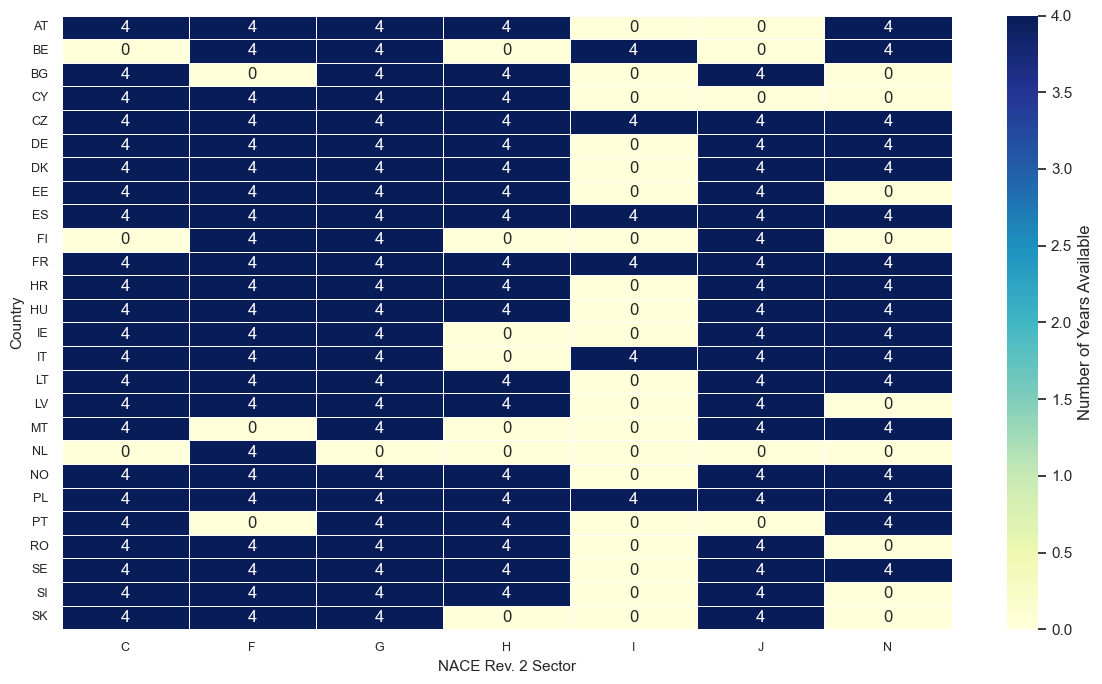

In [ ]:
# Check for missing years (Panel Balance)
coverage_table = pd.crosstab(data['geo'], data['nace_r2'])
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    coverage_table,
    annot=True,
    fmt='d',
    cmap="YlGnBu",
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Number of Years Available'},
    ax=ax
)
ax.set_ylabel('Country', fontsize=11)
ax.set_xlabel('NACE Rev. 2 Sector', fontsize=11)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.savefig('figure1_coverage_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
def panel_summary_statistics(df, variables, entity_col='nace_r2'):
    """
    Calculates summary stats and Within/Between variance for panel data.
    """

    df['panel_id'] = df['geo'] + "_" + df[entity_col]
    
    summary_list = []
    
    for var in variables:
        # Overall stats
        overall_mean = df[var].mean()
        overall_std = df[var].std()
        overall_min = df[var].min()
        overall_max = df[var].max()
        
        # Variance Decomposition
        # Between variance: Variance of the group means
        group_means = df.groupby('panel_id')[var].mean()
        between_std = group_means.std()
        
        # Within variance: Variance of the demeaned data (data - group_mean + overall_mean)
        df[f'{var}_demeaned'] = df[var] - df.groupby('panel_id')[var].transform('mean') + overall_mean
        within_std = df[f'{var}_demeaned'].std()
        
        summary_list.append({
            'Variable': var,
            'Mean': round(overall_mean, 2),
            'Min': round(overall_min, 2),
            'Max': round(overall_max, 2),
            'Overall_Std': round(overall_std, 2),
            'Between_Std': round(between_std, 2),
            'Within_Std': round(within_std, 2)
        })
        
    return pd.DataFrame(summary_list)


all_vars = ['real_wage', 'ai_adoption', 'spec_ict', 'training_ict', 'productivity', 'gdp', 'unempl_r', 'infl_r', 'FSI', 'share_high_skill', 'tert_edu']

summary_table = panel_summary_statistics(data, all_vars)
print(summary_table.to_string(index=False))


        Variable     Mean      Min       Max  Overall_Std  Between_Std  Within_Std
       real_wage    16.59     4.67     50.00         9.60         9.59        0.80
     ai_adoption    10.87     0.05     68.30        11.63        10.73        4.54
        spec_ict    26.59     1.58     98.25        23.56        23.58        1.57
    training_ict    25.89     3.03     84.70        18.37        18.33        1.82
    productivity    70.04    13.66    665.90        71.95        71.46        9.96
             gdp 37223.88 10960.00 104510.00     21130.78     20905.19     3454.54
        unempl_r     5.79     2.20     14.90         2.40         2.33        0.60
          infl_r     5.96     0.70     19.40         4.28         1.95        3.81
             FSI    32.35     0.00     66.47        15.46        15.45        1.36
share_high_skill    36.04     8.04     96.43        23.82        23.83        1.59
        tert_edu    31.06     4.60     85.50        18.81        18.80        1.57


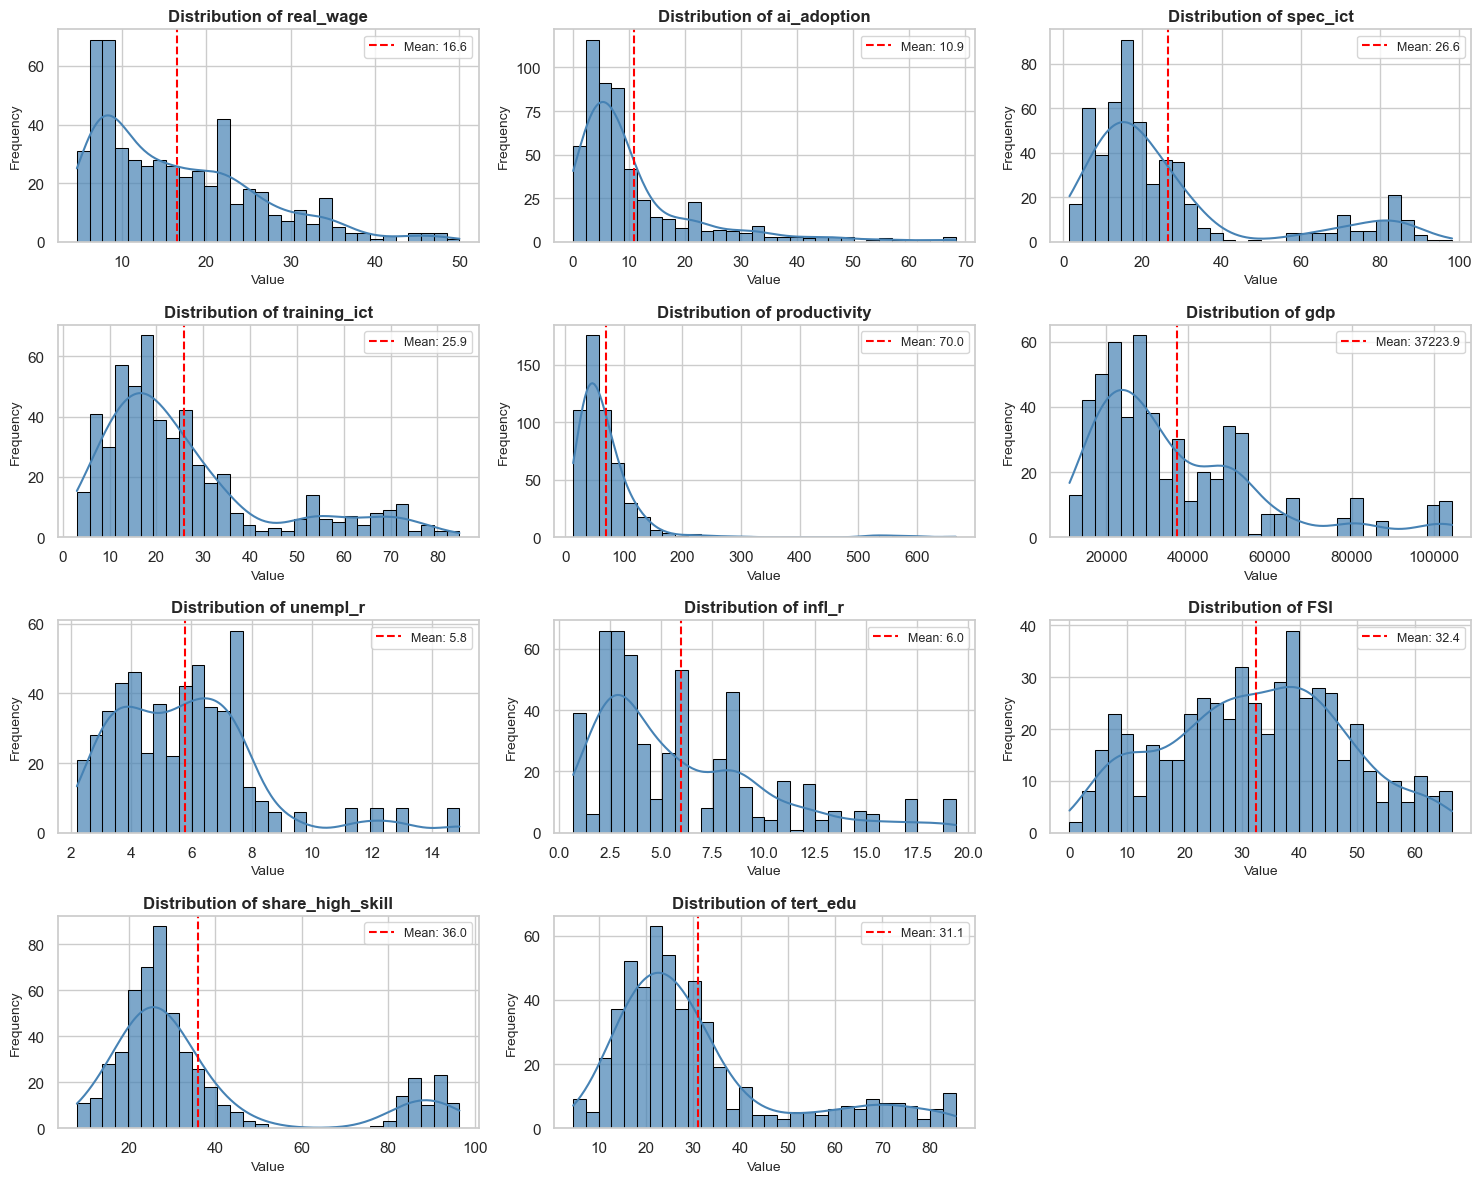

In [12]:
def plot_all_distributions(df):

    vars_to_plot = [var for var in all_vars if var in df.columns]
    
    n_vars = len(vars_to_plot)
    cols = 3
    rows = int(np.ceil(n_vars / cols))
    # sns.set_theme(style="white")
    fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, var in enumerate(vars_to_plot):
        ax = axes[i]
        
        sns.histplot(df[var].dropna(), kde=True, bins=30, color='steelblue', 
                     edgecolor='black', alpha=0.7, ax=ax)
        ax.set_title(f'Distribution of {var}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Value', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        mean_val = df[var].mean()
        ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, 
                   label=f'Mean: {mean_val:.1f}')
        ax.legend(fontsize=9, loc='upper right')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    # fig.suptitle("Histograms and Density Plots for Panel Variables (2021-2024)", 
    #              fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_all_distributions(data)

the average AI adoption for each country across all four years, and benchmark that against the 4-year European average (European average = 100 for interpretation)

In [16]:
def create_ai_intensity_map_period_avg(df):
    df_period = df[df['year'].between(2021, 2024)].copy()

    # 1) Average across industries within each country-year
    country_year = (
        df_period
        .groupby(['geo', 'year'], as_index=False)['ai_adoption']
        .mean()
    )

    # 2) Average across years within each country
    country_avg = (
        country_year
        .groupby('geo', as_index=False)['ai_adoption']
        .mean()
        .rename(columns={'ai_adoption': 'ai_period_avg'})
    )

    # 3) European average of country period averages
    eu_average = country_avg['ai_period_avg'].mean()

    # 4) Build index: EU average = 100
    country_avg['AI_Intensity_Index'] = (country_avg['ai_period_avg'] / eu_average) * 100

    # Eurostat 2-letter codes -> ISO-3
    iso2_to_iso3 = {
        'AT': 'AUT', 'BE': 'BEL', 'BG': 'BGR', 'CY': 'CYP', 'CZ': 'CZE',
        'DE': 'DEU', 'DK': 'DNK', 'EE': 'EST', 'ES': 'ESP', 'FI': 'FIN',
        'FR': 'FRA', 'HR': 'HRV', 'HU': 'HUN', 'IE': 'IRL', 'IT': 'ITA',
        'LT': 'LTU', 'LV': 'LVA', 'MT': 'MLT', 'NL': 'NLD', 'NO': 'NOR',
        'PL': 'POL', 'PT': 'PRT', 'RO': 'ROU', 'SE': 'SWE', 'SI': 'SVN',
        'SK': 'SVK'
    }

    country_avg['iso3'] = country_avg['geo'].map(iso2_to_iso3)
    country_avg = country_avg.dropna(subset=['iso3'])

    # 5) Choropleth
    fig = px.choropleth(
        country_avg,
        locations='iso3',
        color='AI_Intensity_Index',
        hover_name='geo',
        hover_data={
            'iso3': False,
            'ai_period_avg': ':.2f',
            'AI_Intensity_Index': ':.1f'
        },
        scope='europe',
        color_continuous_scale='Blues',
        labels={
            'AI_Intensity_Index': 'AI Intensity Index',
            'ai_period_avg': 'AI share (2021–2024 avg)'
        }
    )

    fig.update_layout(
        # title={
        #     "text": (
        #         "AI Intensity Index Across Europe (2021–2024 average)"
        #         "<br><span style='font-size:14px;'>"
        #         "Country average benchmarked to the European average = 100"
        #         "</span>"
        #     ),
        #     "x": 0.5,
        #     "xanchor": "center"
        # },
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='equirectangular',
            showland=True,           # Turn on the land rendering
            landcolor='lightgray',   # Color all countries light grey by default
            countrycolor='white'     # Make the borders between countries white

        ),
        coloraxis_colorbar=dict(
            title='Index<br>(EU=100)',
            tickvals=[50, 75, 100, 125, 150],
            ticktext=['50', '75', '100', '125', '150'],
            len=0.75
        )
    )

    fig.show()

    return country_avg

country_map_data = create_ai_intensity_map_period_avg(data)

C:\Users\ydmar\AppData\Roaming\Python\Python312\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




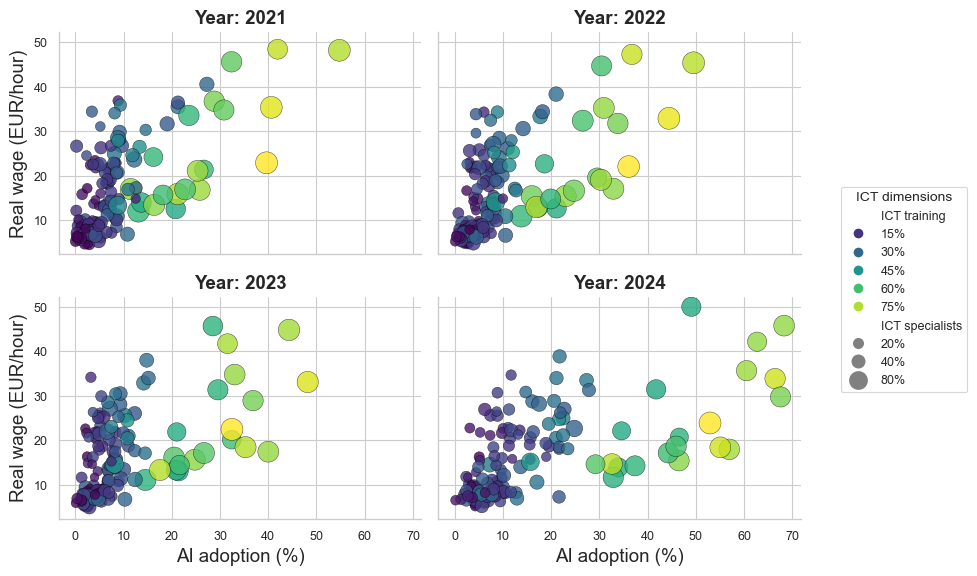

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np

def plot_4d_bubble_facets(df, filename=None):
    # Bigger base fonts for publication
    sns.set_theme(style="whitegrid", context="paper")
    sns.set_context("paper", font_scale=1.4)

    # 2x2 layout instead of 1x4 (more vertical space per panel)
    g = sns.FacetGrid(
        df,
        col="year",
        col_wrap=2,
        height=3.0,      # panel height in inches
        aspect=1.6       # width = height * aspect
    )

    g.map_dataframe(
        sns.scatterplot,
        x="ai_adoption",
        y="real_wage",
        hue="training_ict",
        size="spec_ict",
        sizes=(40, 250),     # slightly larger points
        palette="viridis",
        alpha=0.8,
        edgecolor="black",
        linewidth=0.3,
        legend=False
    )

    g.set_axis_labels("AI adoption (%)", "Real wage (EUR/hour)")
    g.set_titles("Year: {col_name}")

    # Make tick labels readable
    for ax in g.axes.flat:
        ax.tick_params(labelsize=9)

    # Build custom legend (training colour + spec sizes)
    ax = g.axes.flat[-1]
    cmap = plt.cm.viridis
    training_min, training_max = df['training_ict'].min(), df['training_ict'].max()
    training_levels = [15, 30, 45, 60, 75]

    training_norm = plt.Normalize(training_min, training_max)
    color_handles = [
        mlines.Line2D(
            [0], [0],
            marker='o', color='w',
            markerfacecolor=cmap(training_norm(v)),
            markersize=8,
            label=f"{v:.0f}%"
        )
        for v in training_levels
    ]

    spec_min, spec_max = df['spec_ict'].min(), df['spec_ict'].max()
    spec_levels = [20, 40, 80]
    size_min, size_max = 40, 250

    size_handles = [
        mlines.Line2D(
            [0], [0],
            marker='o', color='w',
            markerfacecolor='grey',
            markersize=np.sqrt(size_min + (v - spec_min) / (spec_max - spec_min) * (size_max - size_min)),
            label=f"{v:.0f}%"
        )
        for v in spec_levels
    ]

    training_title = mpatches.Patch(color='none', label='ICT training')
    spec_title = mpatches.Patch(color='none', label='ICT specialists')

    all_handles = [training_title] + color_handles + [spec_title] + size_handles

    g.fig.subplots_adjust(right=0.85)  # leave room for legend
    g.fig.legend(
        handles=all_handles,
        title="ICT dimensions",
        loc='center right',
        bbox_to_anchor=(1.03, 0.50),
        frameon=True,
        fontsize=9,
        title_fontsize=10
    )

    if filename is not None:
        # High-resolution export for Word/PDF
        g.savefig(filename, dpi=300)
    plt.show()

# Example call
plot_4d_bubble_facets(data, filename="figure6_ai_wage_ict_facets.png")

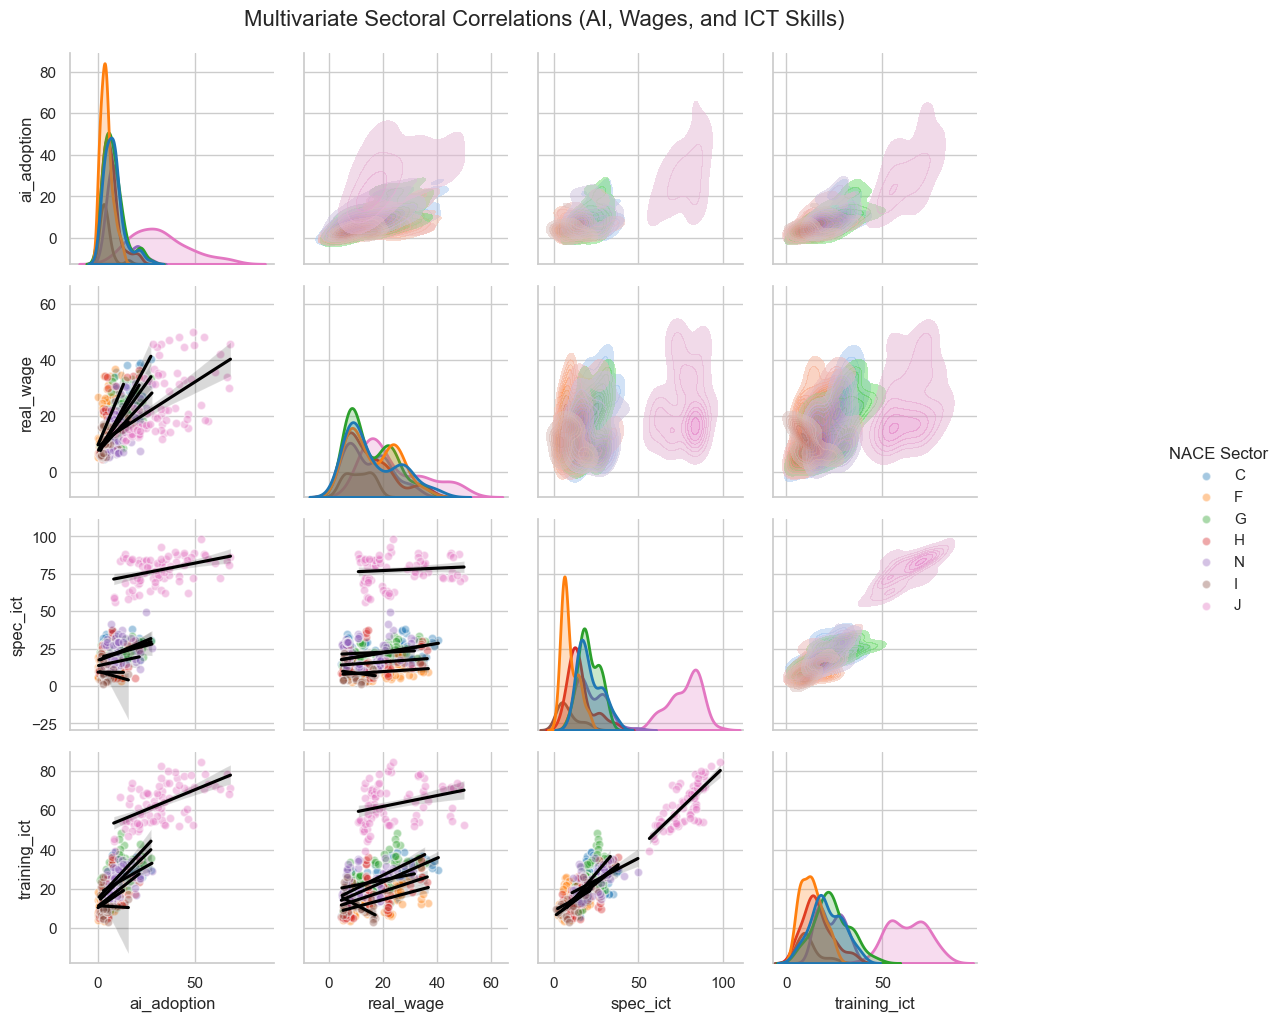

In [7]:
import scipy.stats as stats

def plot_advanced_pairgrid(df):
    # Select only the variables we want to correlate
    vars_to_plot = ['ai_adoption', 'real_wage', 'spec_ict', 'training_ict']
    
    # Create the PairGrid, colored by Industry
    g = sns.PairGrid(df, vars=vars_to_plot, hue="nace_r2", palette="tab10", corner=False)
    
    # 1. Upper Triangle: 2D Density Contours (shows clustering of country-sectors)
    g.map_upper(sns.kdeplot, fill=True, alpha=0.5)
    
    # 2. Lower Triangle: Scatter with Regression Line (shows the trend)
    g.map_lower(sns.regplot, scatter_kws={'alpha':0.4, 'edgecolor':'w'}, line_kws={'color':'black'})
    
    # 3. Diagonal: Density distribution of the variable itself
    g.map_diag(sns.kdeplot, lw=2, fill=True)
    
    g.add_legend(title="NACE Sector", bbox_to_anchor=(1.05, 0.5), loc='center left')
    g.fig.suptitle("Multivariate Sectoral Correlations (AI, Wages, and ICT Skills)", y=1.02, fontsize=16)
    
    plt.show()

# Run it
plot_advanced_pairgrid(data)


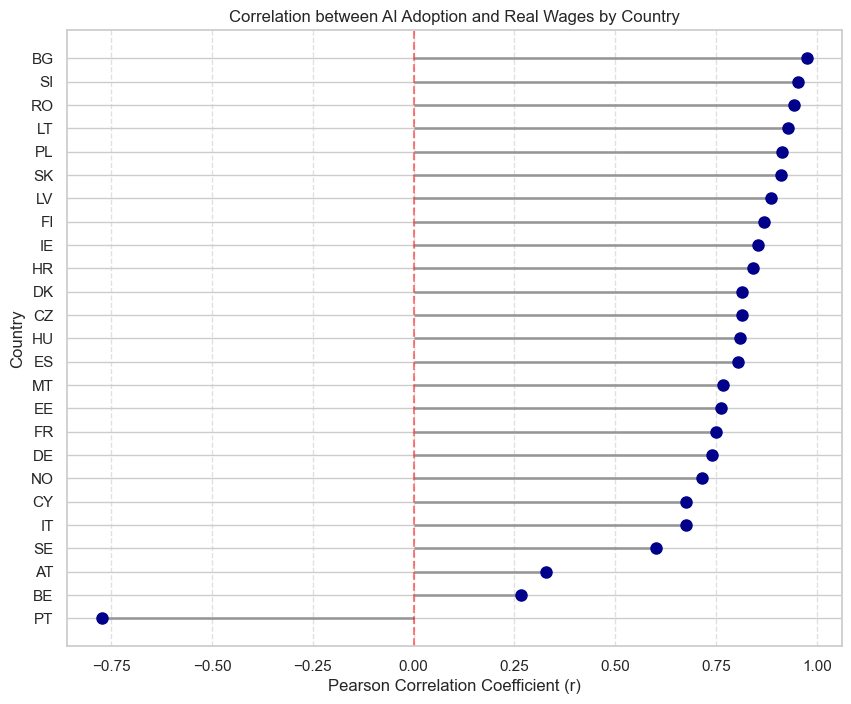

In [8]:
def plot_country_correlations(df):
    # Calculate the correlation between AI Adoption and Real Wage for each country
    correlations = []
    countries = df['geo'].unique()
    
    for country in countries:
        country_data = df[df['geo'] == country]
        # Need enough data points to calculate correlation
        if len(country_data) > 5: 
            corr, _ = stats.pearsonr(country_data['ai_adoption'], country_data['real_wage'])
            correlations.append({'Country': country, 'AI_Wage_Corr': corr})
            
    corr_df = pd.DataFrame(correlations).sort_values(by='AI_Wage_Corr', ascending=True)
    
    # Create the Dot Plot (Lollipop Chart)
    plt.figure(figsize=(10, 8))
    plt.hlines(y=corr_df['Country'], xmin=0, xmax=corr_df['AI_Wage_Corr'], color='gray', alpha=0.7, linewidth=2)
    plt.plot(corr_df['AI_Wage_Corr'], corr_df['Country'], "o", markersize=8, color='darkblue')
    
    # Add a vertical line at 0 for reference
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    
    plt.title("Correlation between AI Adoption and Real Wages by Country")
    plt.xlabel("Pearson Correlation Coefficient (r)")
    plt.ylabel("Country")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

# Run it
plot_country_correlations(data)

In [18]:
def detect_panel_outliers(df, variables):
    """
    Identifies outliers for given variables relative to their NACE sector and Year
    using the Interquartile Range (IQR) method.
    """
    all_outliers = pd.DataFrame()
    
    for var in variables:
        # Group by Industry and Year
        for (industry, year), group in df.groupby(['nace_r2', 'year']):
            # Skip if there's not enough data to calculate quartiles
            if len(group) < 4:
                continue
                
            Q1 = group[var].quantile(0.25)
            Q3 = group[var].quantile(0.75)
            IQR = Q3 - Q1
            
            # Define bounds (1.5 * IQR is the standard econometric threshold)
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Filter rows that fall outside the bounds
            outliers = group[(group[var] < lower_bound) | (group[var] > upper_bound)].copy()
            
            if not outliers.empty:
                # Add descriptive columns
                outliers['Variable'] = var
                outliers['Value'] = outliers[var].round(2)
                outliers['Outlier_Type'] = outliers[var].apply(lambda x: 'High' if x > upper_bound else 'Low')
                outliers['Normal_Max'] = round(upper_bound, 2)
                outliers['Normal_Min'] = round(lower_bound, 2)
                
                # Keep only the identifying information
                outliers_clean = outliers[['geo', 'nace_r2', 'year', 'Variable', 'Value', 
                                           'Outlier_Type', 'Normal_Min', 'Normal_Max']]
                
                all_outliers = pd.concat([all_outliers, outliers_clean], ignore_index=True)
                
    return all_outliers

# 1. Run the extraction for your 4 main variables
core_vars = ['ai_adoption', 'real_wage', 'spec_ict', 'training_ict']
exact_outliers_df = detect_panel_outliers(data, core_vars)

# 2. Display the exact outliers
print("--- Exact Outliers Identified ---")
# Sort by variable and year to make it easy to read
exact_outliers_df = exact_outliers_df.sort_values(by=['Variable', 'year', 'nace_r2'])
print(exact_outliers_df.to_string(index=False))


--- Exact Outliers Identified ---
geo nace_r2  year     Variable  Value Outlier_Type  Normal_Min  Normal_Max
 DK       C  2021  ai_adoption  27.28         High       -4.68       16.96
 DK       G  2021  ai_adoption  21.30         High       -4.50       15.62
 DK       H  2021  ai_adoption  21.28         High       -2.56       13.16
 DK       J  2021  ai_adoption  54.75         High       -5.34       52.50
 DK       N  2021  ai_adoption  19.04         High        2.50       12.42
 NO       N  2021  ai_adoption  14.59         High        2.50       12.42
 DK       C  2022  ai_adoption  21.04         High       -3.25       15.42
 DK       G  2022  ai_adoption  17.74         High       -3.56       15.38
 DK       H  2022  ai_adoption  18.22         High       -2.56       13.69
 DK       H  2023  ai_adoption  15.16         High       -2.85       13.35
 DK       H  2024  ai_adoption  21.10         High       -3.88       19.62
 BE       I  2024  ai_adoption  15.66         High        0.00    

In [19]:
def summarize_outliers(outliers_df):
    print("\n--- Outlier Count by Country ---")
    country_counts = outliers_df['geo'].value_counts()
    print(country_counts[country_counts > 0])
    
    print("\n--- Outlier Count by Industry ---")
    industry_counts = outliers_df['nace_r2'].value_counts()
    print(industry_counts[industry_counts > 0])
    
    print("\n--- Outlier Count by Variable ---")
    var_counts = outliers_df['Variable'].value_counts()
    print(var_counts)

# Run the summary
summarize_outliers(exact_outliers_df)



--- Outlier Count by Country ---
geo
DK    14
CY     7
PL     5
HU     4
IE     2
FI     2
FR     2
NO     1
BE     1
SE     1
Name: count, dtype: int64

--- Outlier Count by Industry ---
nace_r2
H    19
I     8
G     5
N     3
C     2
J     1
F     1
Name: count, dtype: int64

--- Outlier Count by Variable ---
Variable
spec_ict        15
ai_adoption     12
training_ict    12
Name: count, dtype: int64


In [ ]:
def analyze_industry_differences(df):
    nace_labels = {
        'C': 'C: Manufacturing',
        'F': 'F: Construction',
        'G': 'G: Wholesale & Retail',
        'H': 'H: Transportation',
        'I': 'I: Accommodation & Food',
        'J': 'J: Information & Comm.',
        'N': 'N: Admin & Support'
    }
    
    df_plot = df.copy()
    df_plot['industry_name'] = df_plot['nace_r2'].map(nace_labels)

    # Summary statistics for industries over the whole period
    industry_summary = df.groupby('nace_r2')[['real_wage', 'ai_adoption', 'spec_ict']].mean().round(2)
    print("\n--- Average Values by Industry (All Years) ---")
    print(industry_summary.sort_values(by='ai_adoption', ascending=False))
    

    plt.figure(figsize=(14, 7)) 
    order = df_plot.groupby('industry_name')['ai_adoption'].median().sort_values(ascending=False).index
    
    ax = sns.boxplot(
        data=df_plot, 
        x='industry_name', 
        y='ai_adoption', 
        hue='year', 
        order=order, 
        palette='Set2',
        linewidth=1.2
    )
    plt.title('Distribution of AI Adoption by Industry and Year', fontsize=14, pad=15)
    plt.ylabel('AI Adoption Share (%)', fontsize=12)
    plt.xlabel('') # Removed 'NACE Industry' 
    plt.xticks(rotation=15, ha='right', fontsize=10)
    plt.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    plt.tight_layout()
    plt.savefig('ai_adoption_by_industry.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run it on your data
analyze_industry_differences(data)

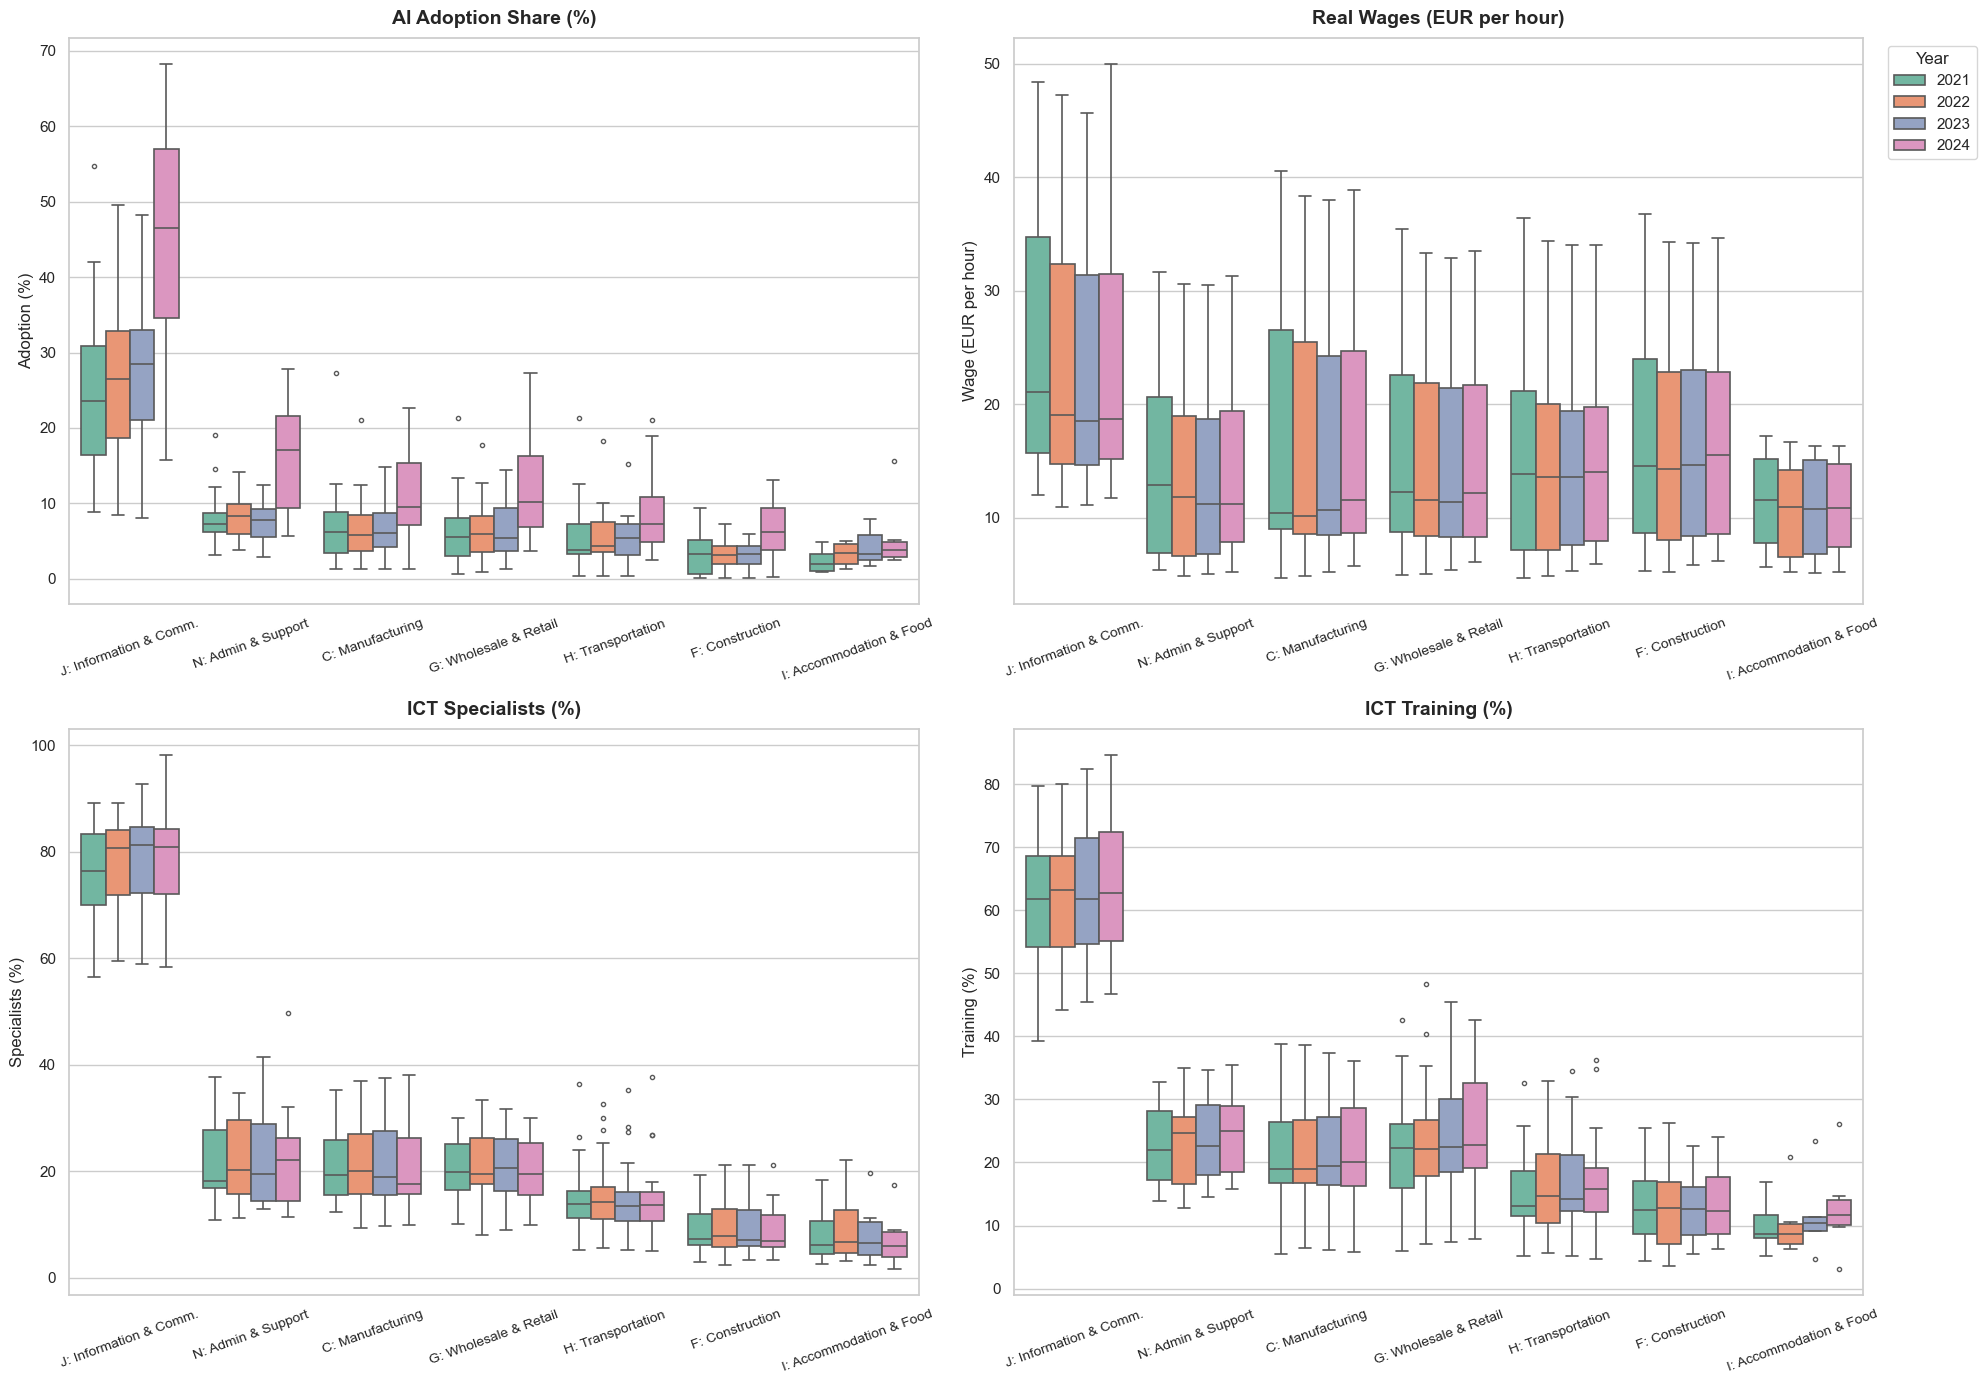

In [28]:
def plot_core_variables_grid(df):
    nace_labels = {
        'C': 'C: Manufacturing', 'F': 'F: Construction', 'G': 'G: Wholesale & Retail',
        'H': 'H: Transportation', 'I': 'I: Accommodation & Food', 
        'J': 'J: Information & Comm.', 'N': 'N: Admin & Support'
    }
    df_plot = df.copy()
    df_plot['industry_name'] = df_plot['nace_r2'].map(nace_labels)

    variables = [
        {'col': 'ai_adoption', 'title': 'AI Adoption Share (%)', 'ylabel': 'Adoption (%)'},
        {'col': 'real_wage', 'title': 'Real Wages (EUR per hour)', 'ylabel': 'Wage (EUR per hour)'},
        {'col': 'spec_ict', 'title': 'ICT Specialists (%)', 'ylabel': 'Specialists (%)'},
        {'col': 'training_ict', 'title': 'ICT Training (%)', 'ylabel': 'Training (%)'}
    ]

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(20, 14)) 
    axes = axes.flatten()

    order = df_plot.groupby('industry_name')['ai_adoption'].median().sort_values(ascending=False).index

    for i, var_info in enumerate(variables):
        ax = axes[i]
        
        sns.boxplot(
            data=df_plot, 
            x='industry_name', 
            y=var_info['col'], 
            hue='year', 
            order=order, 
            palette='Set2',
            linewidth=1.2,
            ax=ax,
            fliersize=3 
        )
        
        ax.set_title(var_info['title'], fontsize=14, fontweight='bold', pad=10)
        ax.set_ylabel(var_info['ylabel'], fontsize=12)
        ax.set_xlabel('') 
        ax.tick_params(axis='x', rotation=20, labelsize=10)
        
        if i == 1: 
            ax.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()
    # fig.suptitle("Dynamics of core variables by Industry and Year (2021-2024)", 
    #              fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_core_variables_grid(data)

In [9]:
def calculate_growth_summary(df):
    # Filter for first and last year
    min_year, max_year = df['year'].min(), df['year'].max()
    
    # Calculate means for the first and last year by industry
    first_year = df[df['year'] == min_year].groupby('nace_r2')['ai_adoption'].mean()
    last_year = df[df['year'] == max_year].groupby('nace_r2')['ai_adoption'].mean()
    
    # Calculate percentage change
    growth = ((last_year - first_year) / first_year) * 100
    
    summary_df = pd.DataFrame({
        f'{min_year} Avg AI': first_year.round(2),
        f'{max_year} Avg AI': last_year.round(2),
        'Growth Rate (%)': growth.round(2)
    }).sort_values(by='Growth Rate (%)', ascending=False)
    
    print(f"\n--- AI Adoption Growth by Industry ({min_year} to {max_year}) ---")
    print(summary_df)

calculate_growth_summary(data)



--- AI Adoption Growth by Industry (2021 to 2024) ---
         2021 Avg AI  2024 Avg AI  Growth Rate (%)
nace_r2                                           
I               2.37         5.61           136.95
G               6.32        12.44            96.65
N               8.28        15.76            90.27
J              25.38        46.71            84.02
F               3.65         6.60            80.82
C               6.99        10.98            57.16
H               5.78         8.57            48.31


### Matrix

In [15]:
print(data)

    geo nace_r2  real_wage  year  ai_adoption  spec_ict  training_ict  \
0    AT       C      26.74  2021        9.610     28.56         22.98   
1    AT       C      26.18  2022       10.960     28.37         25.60   
2    AT       C      26.07  2023       12.310     29.20         25.83   
3    AT       C      27.05  2024       22.710     30.02         26.06   
4    AT       F      22.43  2021        3.120      8.64          8.28   
..   ..     ...        ...   ...          ...       ...           ...   
531  SK       G       8.45  2024       11.650     15.19         19.87   
532  SK       J      15.69  2021       18.190     70.76         55.96   
533  SK       J      14.79  2022       19.905     71.88         53.54   
534  SK       J      14.48  2023       21.620     70.80         58.16   
535  SK       J      14.67  2024       29.190     69.72         62.79   

     productivity    FSI  share_high_skill  tert_edu    hicp  log_prod  \
0          102.25  55.82             36.58      3

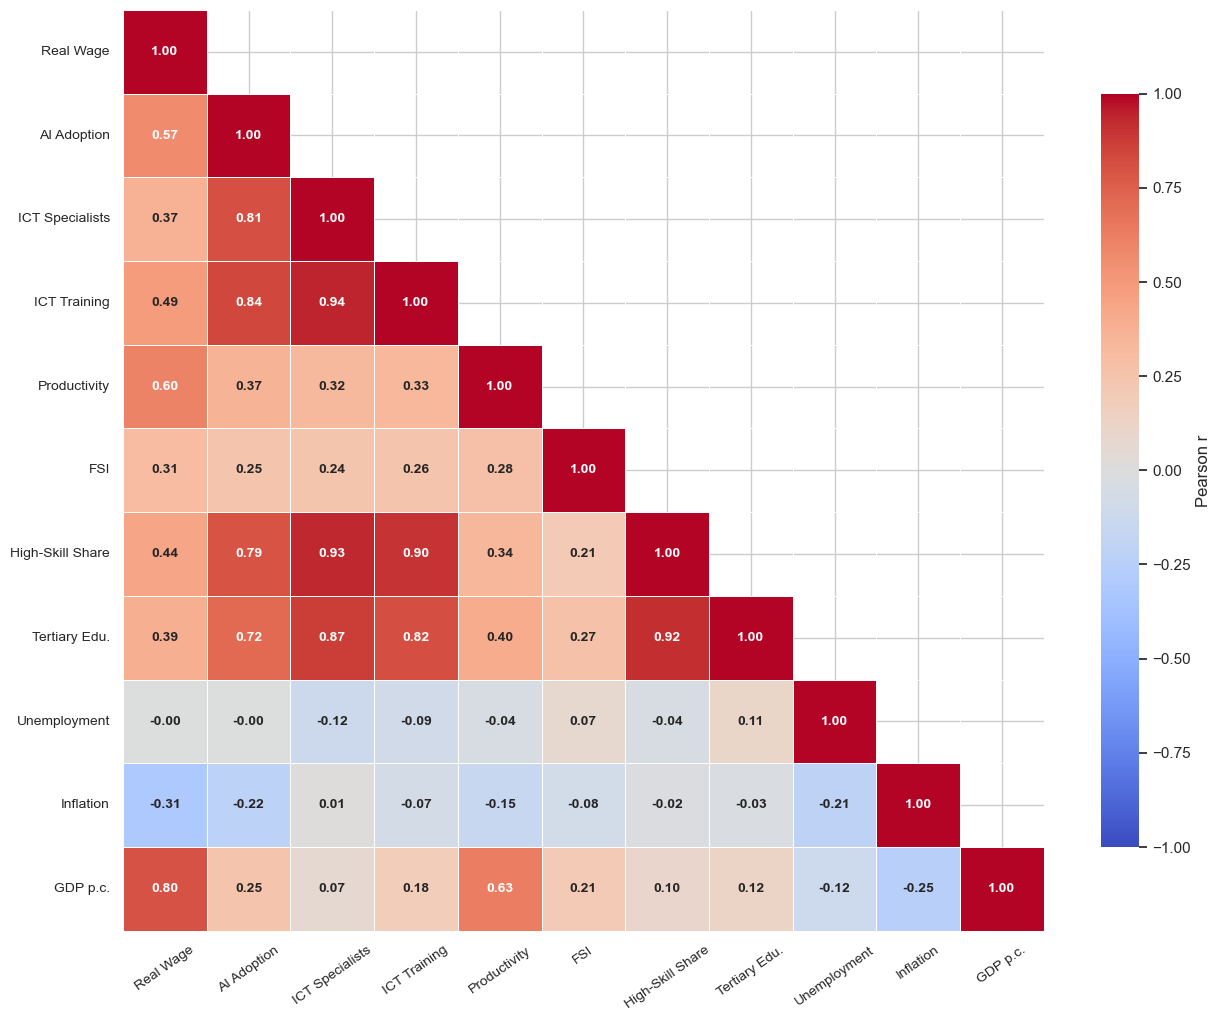

In [13]:
# Choose variables for the matrix

cols = [
    "real_wage", "ai_adoption", "spec_ict", "training_ict", "productivity", "FSI",
    "share_high_skill", "tert_edu", "unempl_r", "infl_r", "gdp"
]

corr = data[cols].corr()

# Mask the upper triangle to avoid redundancy
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Readable variable labels
labels = [
    "Real Wage", "AI Adoption", "ICT Specialists", "ICT Training",
    "Productivity", "FSI", "High-Skill Share", "Tertiary Edu.",
    "Unemployment", "Inflation", "GDP p.c."
]

fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)

ax.tick_params(axis='x', labelsize=10, rotation=35)
ax.tick_params(axis='y', labelsize=10, rotation=0)

plt.tight_layout()
plt.show()
